In [37]:
from classical_laminate_theory.structures import Lamina, Laminate
from classical_laminate_theory.failuremodels import Hashin
from classical_laminate_theory.progressive_failure_analysis import ProgressiveFailureAnalysis
import numpy as np

In [38]:
E1 = 164e9
E2 = 9.1e9
G12 = 5e9
v12 = 0.3
t = 0.3e-3

Xt = 2700e6   #
Xc = 1124e6   #
Yt = 52e6     #
Yc = 170e6    # (Estimated: ~3.3x Yt, typical for Epoxy)
S12 = 80e6    # (Proxy: using Interlaminar Shear )

# helical_angle = 41.81
helical_angle = 54

pressure = 247.5e5
radius = 60e-3


In [39]:
failure_hashin = Hashin(Xt, Xc, Yt, Yc, S12)

hoop = Lamina(90, E1, E2, G12, v12, t, failure_hashin)
helical_a = Lamina(helical_angle, E1, E2, G12, v12, t, failure_hashin)
helical_b = Lamina(-helical_angle, E1, E2, G12, v12, t, failure_hashin)

layup = (hoop, helical_b, helical_a, hoop, helical_a, helical_b)
# layup = (helical_a, helical_b, helical_a, helical_b, helical_a, helical_b)
thickness = len(layup) * t

print("Thickness is:", (thickness * 1000), "mm")

N_hoop = pressure * radius          # Units: (N/m^2) * m = N/m
N_long = N_hoop * 0.5               # Units: N/m

laminate = Laminate(layup, load=np.array([N_long, N_hoop, 0, 0, 0, 0]))

Thickness is: 1.8 mm


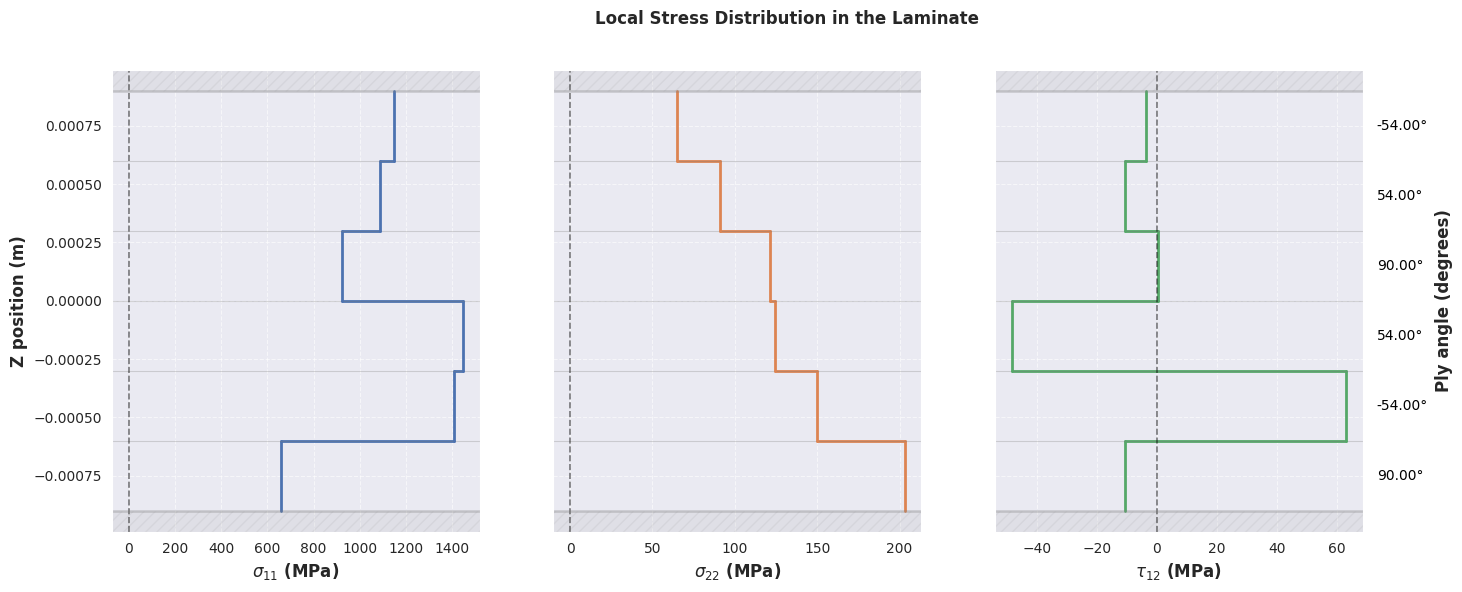

In [40]:
laminate.local_stress_graph

In [41]:
print(f"Applied Pressure: {pressure/1e5} bar")

for i, ply in enumerate(laminate.plies):
    # Retrieve local stress/strain calculated by CLT
    stress = laminate.local_stresses[i]
    strain = laminate.local_strains[i]

    # Ask the ply's failure model to check these values
    # It returns a list of failure modes (e.g., [FailureMode.MATRIX_TENSION])
    failures = ply.failure_model.failure_check(stress, strain)

    ply_angle = np.degrees(ply.angle)

    if len(failures) > 0:
        # Get the names of the failure modes
        failure_names = [f.name for f in failures]
        print(f"Ply {i+1} ({ply_angle:5.2f}°): FAILED -> {failure_names}")
    else:
        print(f"Ply {i+1} ({ply_angle:5.2f}°): SAFE")

Applied Pressure: 247.5 bar
Ply 1 (90.00°): FAILED -> ['MATRIX_TENSION']
Ply 2 (-54.00°): FAILED -> ['MATRIX_TENSION']
Ply 3 (54.00°): FAILED -> ['MATRIX_TENSION']
Ply 4 (90.00°): FAILED -> ['MATRIX_TENSION']
Ply 5 (54.00°): FAILED -> ['MATRIX_TENSION']
Ply 6 (-54.00°): FAILED -> ['MATRIX_TENSION']


--- Starting 'Run Until Failure' PFA ---
  -> STOP: All 6 plies have experienced failure.
  -> Global Failure Detected at Step 833
  -> Max Load Reached: 834000.00 N/m
--- Simulation Complete ---
True Burst Safety Factor: 1.12


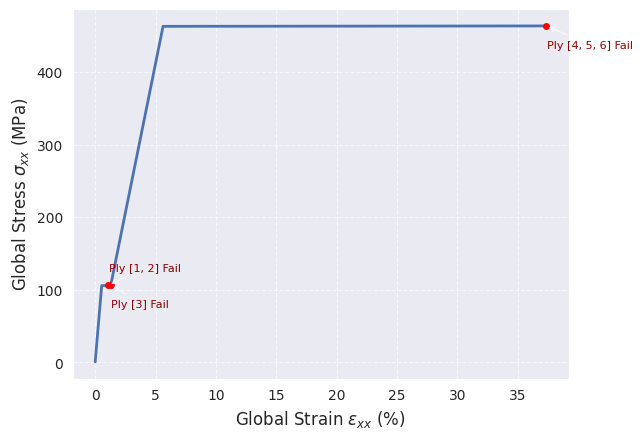

In [42]:
pfa = ProgressiveFailureAnalysis(laminate)
pfa.run_until_failure(np.array([1, 2, 0, 0, 0, 0]), 1000)
pfa.plot_curve()

# Retrieve the maximum Longitudinal load (N_xx) sustained
burst_long_load = max(pfa.history['load_factor'])

# Convert N_xx back to Pressure (P = 2 * N_long / r)
burst_pressure = (burst_long_load * 2) / radius

burst_sf = burst_pressure / pressure
print(f"True Burst Safety Factor: {burst_sf:.2f}")